In [3]:
#installations needed
!pip install tensorflow # need this for neural network model
!pip install  scikeras
!pip install lightgbm --quiet

In [4]:
#import the necessary libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.pipeline import Pipeline
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier as SKKerasClassifier
from sklearn.ensemble import GradientBoostingClassifier
from tensorflow.keras.layers import Dropout,GlobalAveragePooling1D


In [ ]:
#Loading the train,test, and validation datasets:
train_data=pd.read_csv('train.csv')
test_data=pd.read_csv('test.csv')
validation_data=pd.read_csv('val.csv')
#print to check:
train_data.head()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p35,p36,p37,p38,p39,p40,p41,p42,turn,label_move_col
0,0,1,-1,1,-1,0,1,0,1,-1,...,0,0,0,0,0,0,0,0,1,1
1,0,-1,-1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,-1,1
2,0,1,-1,1,0,0,1,0,0,-1,...,0,0,0,0,0,0,0,0,-1,2
3,1,0,0,0,-1,1,1,-1,0,0,...,0,0,0,0,0,0,0,0,-1,3
4,1,1,-1,-1,-1,1,-1,1,0,0,...,1,-1,0,0,0,0,0,1,-1,4


label_move_col
3    17653
6     7136
0     7136
4     4923
2     4923
1     4111
5     4111
Name: count, dtype: int64


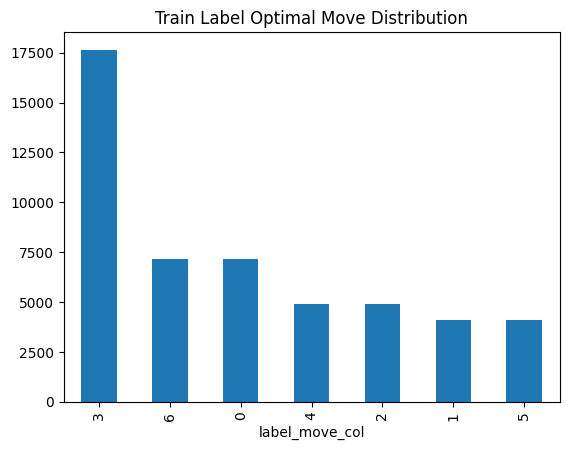

In [ ]:
#Explore label distribution and patterns:

#count the number of times each optimal move occured
count=train_data['label_move_col'].value_counts()
print(count)
#Plot it to visualize:
count.plot(kind='bar')
plt.title('Train Label Optimal Move Distribution')
plt.show()


In [ ]:
#convert the turn column of -1 and 1 into 0 and 1 instead, (numerical to binary feature)( commented out as it had no use)
#train_data['turn']=train_data['turn'].map({-1:0,1:1})
#validation_data['turn']=validation_data['turn'].map({-1:0,1:1})
#test_data['turn']=test_data['turn'].map({-1:0,1:1})

#divide train data into input and label:
X_train=train_data.drop('label_move_col',axis=1)
y_train=train_data['label_move_col']
X_val=validation_data.drop('label_move_col',axis=1)
y_val=validation_data['label_move_col']
X_test = test_data.drop('id', axis=1)







# Decision Tree Model

              precision    recall  f1-score   support

           0       0.35      0.36      0.36      1450
           1       0.38      0.39      0.38       925
           2       0.40      0.41      0.40      1033
           3       0.68      0.66      0.67      3958
           4       0.40      0.41      0.41      1033
           5       0.39      0.39      0.39       925
           6       0.36      0.36      0.36      1450

    accuracy                           0.49     10774
   macro avg       0.42      0.43      0.42     10774
weighted avg       0.49      0.49      0.49     10774

Baseline Accuracy:  0.48552069797661035


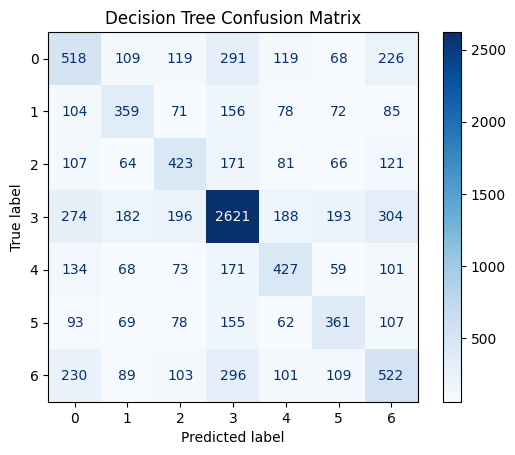

In [ ]:
#Decision Tree Model
#Step 1: creating the model:
DecisionTree_model = DecisionTreeClassifier(random_state=42, class_weight="balanced")


#Step 2: model training
DecisionTree_model.fit(X_train,y_train)

#Step 3: prediction using validation data:
y_pred_val=DecisionTree_model.predict(X_val)

#Step 4: Evaluate the model
print(classification_report(y_val,y_pred_val))
print("Baseline Accuracy: ", accuracy_score(y_val,y_pred_val))

#Step 5: print the confusion matrix
Confusion_Matrix=confusion_matrix(y_val,y_pred_val)
display=ConfusionMatrixDisplay(confusion_matrix=Confusion_Matrix,display_labels=DecisionTree_model.classes_)
display.plot(cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()


The results show an accuracy of 0.486% when using the decision tree model.

In [ ]:
# Testing to see why i obtained poor results:

y_pred_train=decision_tree_model.predict(X_train)
print("Train data accuracy score using decision tree model ", accuracy_score(y_train,y_pred_train))
print("Validation data accuracy score using decision tree model ", accuracy_score(y_val,y_pred_val))

Train data accuracy score using decision tree model  0.9920788910447462
Validation data accuracy score using decision tree model  0.4860775942082792


Since the model does better on training data compared to the validation data (there is a big gap), the reason why the accuracy is low is likely due to overfitting.

#

# Logistic Regression Model

C=100 --> Accuracy=0.5222758492667533


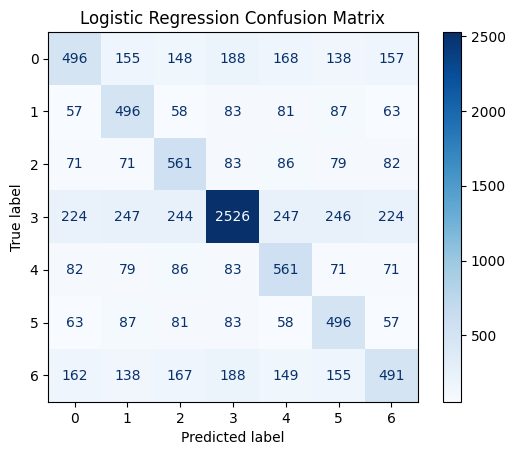

In [ ]:
#Logistic Regression Model

feature_list = [f"p{i}" for i in range(1, 43)] + ['turn']
train_x = train_data[feature_list]
train_y = train_data['label_move_col']
validation_x = validation_data[feature_list]
validation_y = validation_data['label_move_col']

# Polynomial Features degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
train_x_poly = poly.fit_transform(train_x)
validation_x_poly = poly.transform(validation_x)

# Logistic Regression with regularization
# C_values = [0.01, 0.1, 1, 10, 100], were tested, with C=100 giving the best accuracy
#for c in C_values:
log_reg = LogisticRegression(
    C=100,               # regularization strength
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
log_reg.fit(train_x_poly, train_y)
y_pred = log_reg.predict(validation_x_poly)
acc = accuracy_score(validation_y, y_pred)
print(f"C=100 --> Accuracy={acc}")

# Confusion Matrix
con_mat = confusion_matrix(validation_y, y_pred)
display=ConfusionMatrixDisplay(confusion_matrix=con_mat,display_labels=log_reg.classes_)
display.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()





# Random Forest Model


 Random Forest Run 1: {'n_estimators': 300, 'max_depth': None} 
Validation Accuracy: 0.5894746612214591
              precision    recall  f1-score   support

           0      0.480     0.461     0.470      1450
           1      0.579     0.376     0.456       925
           2      0.562     0.433     0.489      1033
           3      0.653     0.865     0.744      3958
           4      0.556     0.431     0.486      1033
           5      0.583     0.375     0.457       925
           6      0.499     0.465     0.481      1450

    accuracy                          0.589     10774
   macro avg      0.559     0.486     0.512     10774
weighted avg      0.579     0.589     0.573     10774



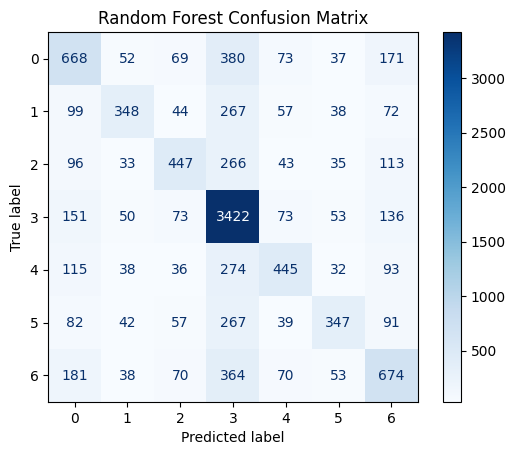


Best of the settings: {'n_estimators': 300, 'max_depth': None} with acc = 0.5894746612214591
Done: submission.csv


In [ ]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier
# try a few manual settings (for faster runtime we kept the best result and turned the others into comments)
rf_settings = [
    {"n_estimators": 300, "max_depth": None},  # best so far with Accuracy: 0.58947
    # {"n_estimators": 350, "max_depth": None},
    # {"n_estimators": 100, "max_depth": None},
    # {"n_estimators": 300, "max_depth": 20},
]

# testing loop to get the best accuracy
best_acc = -1.0
best_params = None

for i, params in enumerate(rf_settings, 1):
    print(f"\n Random Forest Run {i}: {params} ")
    rf = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        max_features="sqrt",
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight=None,
        n_jobs=-1,
        random_state=42,
        bootstrap=True,
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    print("Validation Accuracy:", acc)
    print(classification_report(y_val, y_pred, digits=3))

    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title("Random Forest Confusion Matrix")
    plt.show()

    if acc > best_acc:
        best_acc = acc
        best_params = params

print("\nBest of the settings:", best_params, "with acc =", best_acc)

# train final model with the best setting from the loop on all labeled data
final_rf = RandomForestClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    max_features='sqrt',
    min_samples_leaf=1,
    bootstrap=True,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

# we combined training set with validation for the final model to train on
full_X =pd.concat([X_train, X_val], axis=0)
full_y = pd.concat([y_train, y_val], axis=0)
final_rf.fit(full_X, full_y)

# predict and save as required: id + label_move_col
test_pred = final_rf.predict(X_test)
submission = pd.DataFrame({
    "id": test_data['id'] if 'id' in test_data.columns else np.arange(1, len(test_pred) + 1, dtype=int),
    "label_move_col": test_pred
})
submission.to_csv("submission.csv", index=False)
print("Done: submission.csv")

#Enhancing the dataset with feature engineering for advanced models


In [ ]:
#Enhancing the dataset with feature engineering for advanced models
# Get the board columns p1–p42
board_cols = [col for col in X_train.columns if col.startswith('p')]

# Multiply each board cell by its turn value
X_train[board_cols] = X_train[board_cols].multiply(X_train['turn'], axis=0)
X_val[board_cols]   = X_val[board_cols].multiply(X_val['turn'], axis=0)
X_test[board_cols]  = X_test[board_cols].multiply(X_test['turn'], axis=0)

# Drop turn column
X_train = X_train.drop(columns=['turn'])
X_val   = X_val.drop(columns=['turn'])
X_test  = X_test.drop(columns=['turn'])

# Display a few transformed samples
print("\nSample transformed training rows:")
print(X_train.head())


Sample transformed training rows:
   p1  p2  p3  p4  p5  p6  p7  p8  p9  p10  ...  p33  p34  p35  p36  p37  p38  \
0   0   1  -1   1  -1   0   1   0   1   -1  ...    0    0    0    0    0    0   
1   0   1   1  -1   0   0   0   0  -1    0  ...    0    0    0    0    0    0   
2   0  -1   1  -1   0   0  -1   0   0    1  ...    0    0    0    0    0    0   
3  -1   0   0   0   1  -1  -1   1   0    0  ...    0    0    0    0    0    0   
4  -1  -1   1   1   1  -1   1  -1   0    0  ...    0    0   -1    1    0    0   

   p39  p40  p41  p42  
0    0    0    0    0  
1    0    0    0    0  
2    0    0    0    0  
3    0    0    0    0  
4    0    0    0   -1  

[5 rows x 42 columns]


# XGBoost


In [ ]:
#Step 1: creating the XGBoost model (this is the baseline)
XGBoost= XGBClassifier(random_state=42)
#Step 2: fit on the training data
XGBoost.fit(X_train,y_train)
#Step 3: predicting
y_pred_val=XGBoost.predict(X_val)
#Step 4: the results
print(classification_report(y_val,y_pred_val))



              precision    recall  f1-score   support

           0       0.46      0.39      0.42      1450
           1       0.61      0.49      0.54       925
           2       0.61      0.52      0.56      1033
           3       0.69      0.87      0.77      3958
           4       0.61      0.52      0.56      1033
           5       0.61      0.50      0.55       925
           6       0.47      0.40      0.43      1450

    accuracy                           0.61     10774
   macro avg       0.58      0.53      0.55     10774
weighted avg       0.60      0.61      0.60     10774



In [ ]:
#Modified XGBoost model
#hyperparameter tuning to obtain better results than the baseline

param_distribution = {
    'n_estimators': [200,250,300,350,400],
    'max_depth': [3,7,10,15,20],
    'learning_rate': [0.01,0.1,0.2],
    'subsample': [0.5, 0.7,1],
    'colsample_bytree': [0.5, 0.7],
    'lambda': [0.01,0.1, 1.0, 10.0]
    }
XGBoostModified= XGBClassifier()
Rsearch = RandomizedSearchCV(estimator=XGBoostModified, param_distributions=param_distribution, scoring='accuracy',cv=3, random_state=42)
Rsearch.fit(X_train, y_train)
print("Best parameters:", Rsearch.best_params_)

Best parameters: {'subsample': 1, 'n_estimators': 400, 'max_depth': 20, 'learning_rate': 0.1, 'lambda': 10.0, 'colsample_bytree': 0.7}


              precision    recall  f1-score   support

           0       0.49      0.46      0.48      1450
           1       0.62      0.55      0.59       925
           2       0.63      0.59      0.61      1033
           3       0.75      0.85      0.80      3958
           4       0.63      0.58      0.60      1033
           5       0.63      0.56      0.59       925
           6       0.49      0.46      0.48      1450

    accuracy                           0.64     10774
   macro avg       0.61      0.58      0.59     10774
weighted avg       0.64      0.64      0.64     10774



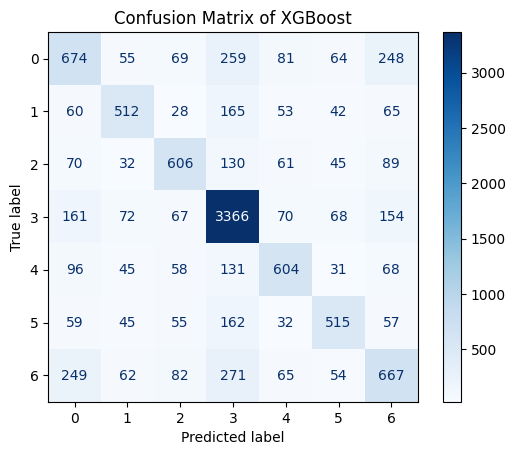

Modified XGBoost accuracy: %  64.4514572118062


In [ ]:
XGBoostModified=XGBClassifier(**Rsearch.best_params_,random_state=42,objective="multi:softprob")
XGBoostModified.fit(X_train,y_train)
y_pred_val=XGBoostModified.predict(X_val)
#results:
print(classification_report(y_val,y_pred_val))
#confusion matrix:
cm = confusion_matrix(y_val, y_pred_val)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title(f"Confusion Matrix of XGBoost")
plt.show()
#accuracy
XGMaccuracy=accuracy_score(y_val,y_pred_val)
print("Modified XGBoost accuracy: % ",XGMaccuracy*100)


In [ ]:
#after running, the XGBoostModified has better results, so we used it to submit a file on kaggle.
# we combined training set with validation for the final model to train on
full_X = pd.concat([X_train, X_val], axis=0)
full_y = pd.concat([y_train, y_val], axis=0)
XGBoostModified.fit(full_X,full_y)

# predict and save as required: id + label_move_col
test_pred = XGBoostModified.predict(X_test)
submission = pd.DataFrame({
    "id":test_data["id"] if "id" in test_data.columns else np.arange(1, len(test_pred) + 1, dtype=int),
    "label_move_col": test_pred
})
submission.to_csv("submission.csv", index=False)
print("Done: submission.csv")

Done: submission.csv


#Neural Network


In [ ]:
#Neural Network Model
tf.keras.utils.set_random_seed(42)

#Step 1: creating the neural network model archeticture:
NNmodel = keras.Sequential([
    Dense(128, input_shape=(X_train.shape[1],), activation='relu'),    #activation function is ReLU or
    Dropout(0.2),                   #dropout layer to prevent overfitting
    Dense(64, activation='relu'),
    Dropout(0.2),  #dropout layer to prevent overfitting
    Dense(32, activation='relu'),
    Dropout(0.2),  #dropout layer to prevent overfitting
    Dense(7, activation='softmax') #output layer
])


#Step 2: compile the model
NNmodel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#Step 3: Train the model
history=NNmodel.fit(X_train, y_train, epochs=120, batch_size=32, validation_data=(X_val, y_val))

#Step 4: evaluate the model
val_loss, val_acc = NNmodel.evaluate(X_val, y_val)
print('Neural Network accuracy: %', val_acc*100)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/120
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.3497 - loss: 1.7882 - val_accuracy: 0.4257 - val_loss: 1.5312
Epoch 2/120
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4059 - loss: 1.5766 - val_accuracy: 0.4561 - val_loss: 1.4501
Epoch 3/120
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4321 - loss: 1.5061 - val_accuracy: 0.4888 - val_loss: 1.3846
Epoch 4/120
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4586 - loss: 1.4528 - val_accuracy: 0.5077 - val_loss: 1.3338
Epoch 5/120
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4721 - loss: 1.4109 - val_accuracy: 0.5201 - val_loss: 1.3096
Epoch 6/120
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4814 - loss: 1.3918 - val_accuracy: 0.5278 - val_loss: 1.2879
Epoch 7/120
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4919 - loss: 1.3688 - val_accuracy: 0.5360 - val_loss: 1.2665
Epoch 8/120
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5040 - loss: 1

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


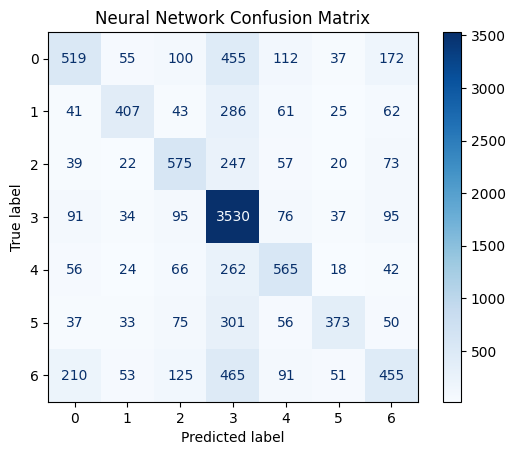

In [ ]:
#predict and create the confusion matrix
y_pred=NNmodel.predict(X_val)
y_pred=np.argmax(y_pred,axis=1)
ConfusionMatrix=confusion_matrix(y_val,y_pred)
ConfusionMatrixDisplay(confusion_matrix=ConfusionMatrix).plot(cmap="Blues")
plt.title('Neural Network Confusion Matrix')
plt.show()

#Gradient Boosting model

In [ ]:
#Gradient Boosting Model
best_gb = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,           # reduces variance
    min_samples_split=5,     # prevents overfitting
    min_samples_leaf=2,
    random_state=42
)

# Train the model on the training data
best_gb.fit(X_train, y_train)

# Predict on validation data
y_pred_val = best_gb.predict(X_val)
acc = accuracy_score(y_val, y_pred_val)
print("Gradient Boosting accuracy: %'", acc)




Gradient Boosting accuracy: %' 0.6272507889363282


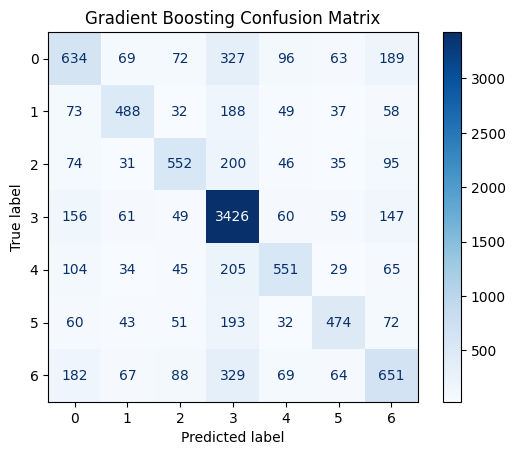

In [ ]:
cm = confusion_matrix(y_val, y_pred_val)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

#LightGBM model

#

In [ ]:
#LightGBM Model
import lightgbm as lgb

# Prepare datasets
train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Parameters
params = {
    'objective': 'multiclass',
    'num_class': 7,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 4,
    'min_data_in_leaf': 50,
    'max_depth': -1,
    'lambda_l1': 0.1,
    'lambda_l2': 1.0,
    'random_state': 42
}

# Correct way to handle early stopping (via callbacks)
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50)
]

# Train model
model_lgb = lgb.train(
    params=params,
    train_set=train_data,
    valid_sets=[val_data],
    num_boost_round=1000,
    callbacks=callbacks
)

# Predictions
y_pred = np.argmax(model_lgb.predict(X_val, num_iteration=model_lgb.best_iteration), axis=1)
val_acc = accuracy_score(y_val, y_pred)
print(f"LightGBM accuracy:%  {val_acc:.4f}")

# Retrain on Full Data (train + val)
X_full = np.concatenate([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

full_data = lgb.Dataset(X_full, label=y_full)

final_model = lgb.train(
    params=params,
    train_set=full_data,
    num_boost_round=model_lgb.best_iteration  # use best iteration from validation
)

test_pred = np.argmax(final_model.predict(X_test), axis=1)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 126
[LightGBM] [Info] Number of data points in the train set: 49993, number of used features: 42
[LightGBM] [Info] Start training from score -1.946731
[LightGBM] [Info] Start training from score -2.498217
[LightGBM] [Info] Start training from score -2.317965
[LightGBM] [Info] Start training from score -1.040977
[LightGBM] [Info] Start training from score -2.317965
[LightGBM] [Info] Start training from score -2.498217
[LightGBM] [Info] Start training from score -1.946731
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 1.1375
[100]	valid_0's multi_logloss: 1.05929
[150]	valid_0's multi_logloss: 1.03441
[200]	valid_0's multi_logloss: 1.01832
[250]	valid_0's multi_logloss: 1.0068
[300]	valid_0's m

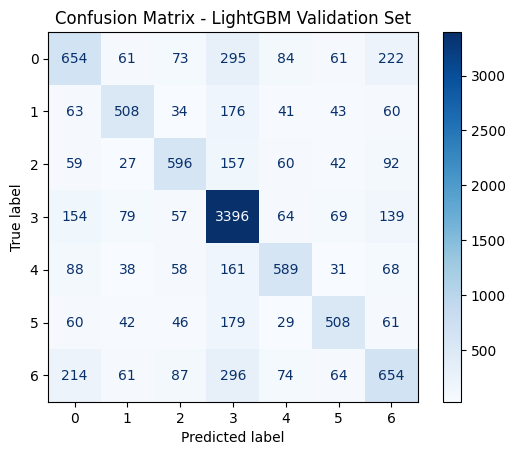

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - LightGBM Validation Set")
plt.show()

# CNN

In [ ]:
#Loading the train,test, and validation datasets:
train_data=pd.read_csv('train.csv')
test_data=pd.read_csv('test.csv')
validation_data=pd.read_csv('val.csv')

#divide train data into input and label:
X_train=train_data.drop('label_move_col',axis=1)
y_train=train_data['label_move_col']
X_val=validation_data.drop('label_move_col',axis=1)
y_val=validation_data['label_move_col']
X_test = test_data.drop('id', axis=1)


In [6]:
def cnn_feature_engineering(data):
  data=data.copy() #copy the data
  # Get the board columns p1–p42
  grid_cols = [col for col in data.columns if col.startswith('p')]
  # Multiply board cell by its turn value
  data[grid_cols] = data[grid_cols].multiply(data['turn'], axis=0)
  # Drop turn column
  data = data.drop(columns=['turn'])

  grid=data[grid_cols].values.reshape(-1,6,7) #change the shape into a grid, 6 rows and 7 columns

#I converted the board into 3 different channels, channel 1 for the current player, channel 2 for the oponnent, and channel 3 for the empyt cell
#So the CNN can understand the shape of the grid better
  current_player= (grid==1).astype("float32")
  opponent_player=(grid==-1).astype("float32")
  empty_cell=(grid==0).astype("float32")

  x_gird= np.stack([current_player,opponent_player,empty_cell],axis=-1) # stack the channels into a tensor
  return x_gird


In [7]:
#reshape for CNN
X_train_CNN=cnn_feature_engineering(X_train)
X_val_CNN=cnn_feature_engineering(X_val)
X_test_CNN=cnn_feature_engineering(X_test)

In [8]:


def createCNN():
  #regularization
 l2_reg=keras.regularizers.l2(0.01)
 model=Sequential([
      Conv2D(32,kernel_size=(3,3),activation='relu', padding='same', input_shape=(6,7,3),kernel_regularizer=l2_reg), #input shape is (6,7,3) because we have 6 rows, 7 columns, and 3 channels (from FE)
      BatchNormalization(),

      Conv2D(32,kernel_size=(3,3),activation='relu',padding='same',kernel_regularizer=l2_reg),
      BatchNormalization(),

      MaxPooling2D(pool_size=(2,2)),


      Conv2D(64,kernel_size=(3,3),activation='relu',padding='same',kernel_regularizer=l2_reg),
      BatchNormalization(),

      Conv2D(64,kernel_size=(3,3),activation='relu',padding='same',kernel_regularizer=l2_reg),
      BatchNormalization(),


      Flatten(),
      Dense(128,activation='relu'),
      Dropout(0.4),
      Dense(64,activation='relu'),
      Dropout(0.3),
      Dense(7,activation='softmax'),

  ])
 model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
 model.summary()
 return model



In [ ]:

#fixed seed to reproduce
tf.random.set_seed(42)
np.random.seed(42)
CNN_model= createCNN()
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3) #learning rate will be reduced by half if no improvement seen after 3 epochs
early_stopping=EarlyStopping(monitor='val_loss',patience=8, restore_best_weights=True)
history=CNN_model.fit(X_train_CNN, y_train, validation_data=(X_val_CNN, y_val), batch_size=32, epochs=50, callbacks=[lr_scheduler,early_stopping],verbose=1)

val_loss, val_acc = CNN_model.evaluate(X_val_CNN, y_val)
print('CNN accuracy: %', val_acc*100)



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 6, 7, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 6, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 6, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 6, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,903 (581.65 KB)

 Trainable params: 148,519 (580.15 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.3425 - loss: 2.5888 - val_accuracy: 0.3865 - val_loss: 1.7344 - learning_rate: 0.0010
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.3902 - loss: 1.7333 - val_accuracy: 0.5260 - val_loss: 1.5493 - learning_rate: 0.0010
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.5163 - loss: 1.5632 - val_accuracy: 0.5698 - val_loss: 1.4485 - learning_rate: 0.0010
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.5684 - loss: 1.4407 - val_accuracy: 0.6077 - val_loss: 1.3282 - learning_rate: 0.0010
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.5905 - loss: 1.3809 - val_accuracy: 0.6155 - val_loss: 1.2834 - learning_rate: 0.0010
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.6011 - loss: 1.3328 - val_accuracy: 0.6234 - val_loss: 1.2623 - learning_rate: 0.0010
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accura

337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


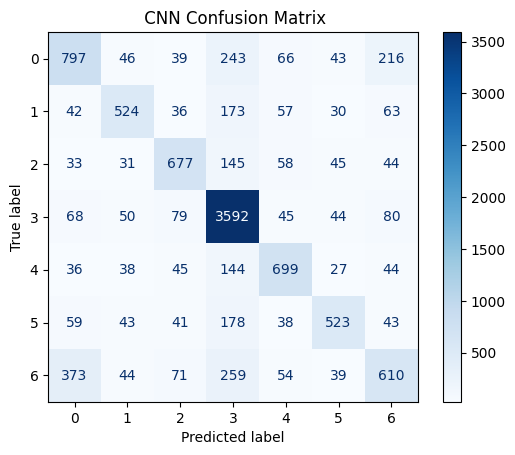

In [ ]:
#predict and create the confusion matrix
y_pred=CNN_model.predict(X_val_CNN)
y_pred=np.argmax(y_pred,axis=1)
ConfusionMatrix=confusion_matrix(y_val,y_pred)
ConfusionMatrixDisplay(confusion_matrix=ConfusionMatrix).plot(cmap="Blues")
plt.title(' CNN Confusion Matrix')
plt.show()

In [ ]:

# predict and save as required: id + label_move_col
test_pred_probs = CNN_model.predict(X_test_CNN)
test_pred= np.argmax(test_pred_probs, axis=1)
submission = pd.DataFrame({
    "id":test_data["id"] if "id" in test_data.columns else np.arange(1, len(test_pred) + 1, dtype=int),
    "label_move_col": test_pred
})
submission.to_csv("submission.csv", index=False)
print("Done: submission.csv")

340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Done: submission.csv
